In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

c:\Users\hieno\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🟩 Subplots with Bar Charts (2.13.1) - Problem

Create a subplot with 2 rows and 1 column:

* In the first subplot, plot a bar chart of the top 3 job locations by the number of job postings.
* In the second subplot, plot a horizontal bar chart of the top 3 job titles by the number of job postings.
* Use tight_layout() to adjust the spacing between subplots.

In [2]:
df_explode = df.copy()

df_job_location = df_explode['job_location'].value_counts().head(3)
df_job_title = df_explode['job_title_short'].value_counts().head(3)


In [3]:
df_job_location.index.to_list()

['Anywhere', 'Singapore', 'Paris, France']

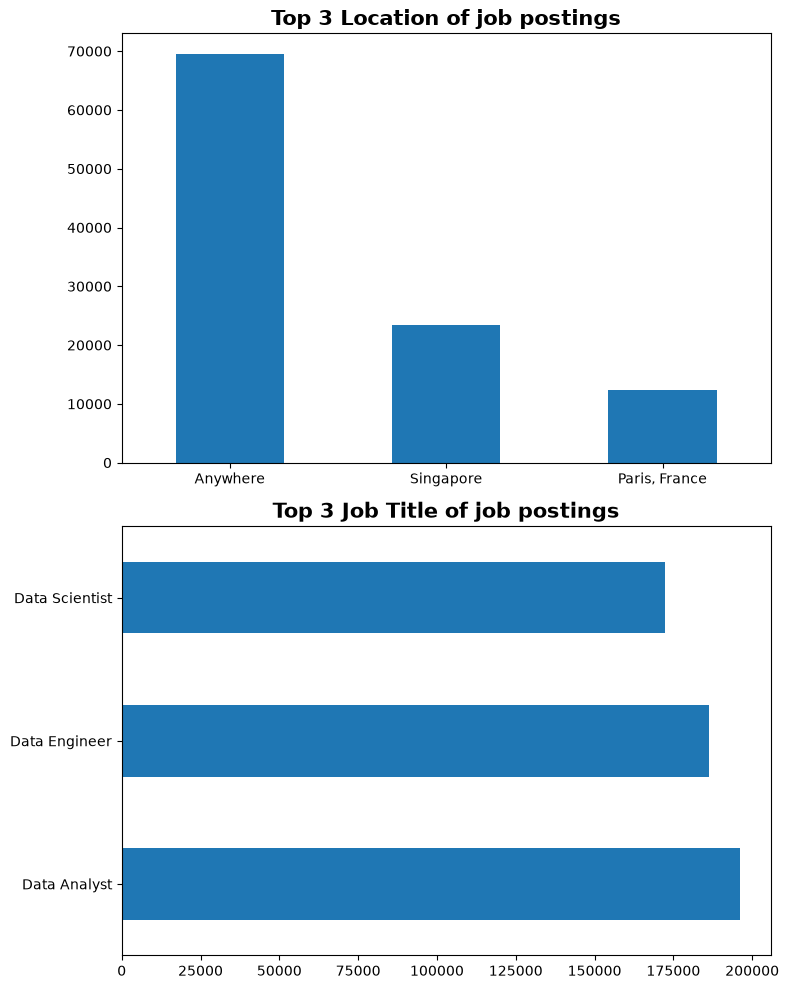

In [4]:
fig, ax = plt.subplots(2, 1, figsize = (8, 10))

df_job_location.plot(kind = 'bar', ax=ax[0])
ax[0].set_title('Top 3 Location of job postings', fontsize = 15, fontweight = 'bold')
ax[0].set_xlabel('')
ax[0].set_xticklabels(df_job_location.index.to_list(), rotation = 0)



df_job_title.plot(kind = 'barh', ax=ax[1])
ax[1].set_title('Top 3 Job Title of job postings', fontsize = 15, fontweight = 'bold')
ax[1].set_ylabel('')
ax[1].set_xlabel('')

fig.tight_layout()
plt.show()

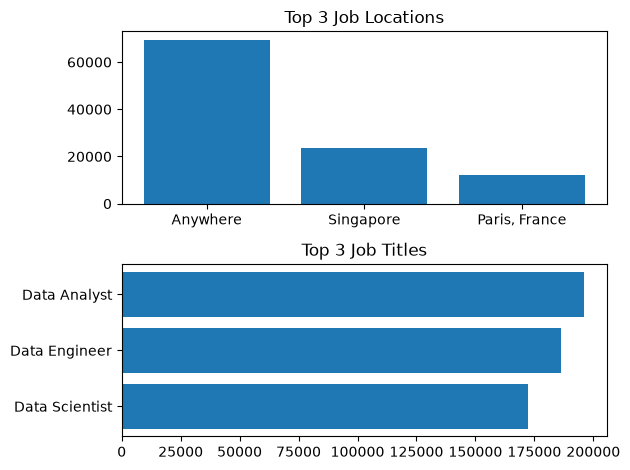

In [5]:
fig, ax = plt.subplots(2, 1)

# Top 3 job locations
job_locations = df['job_location'].value_counts().head(3)
ax[0].bar(job_locations.index, job_locations.values)
ax[0].set_title('Top 3 Job Locations')

# Top 3 job titles
job_titles = df['job_title_short'].value_counts().head(3)
ax[1].barh(job_titles.index, job_titles.values)
ax[1].set_title('Top 3 Job Titles')
ax[1].invert_yaxis()

fig.tight_layout()
plt.show()

## 🟨 Subplots with Job Titles by Schedule (2.13.2) - Problem

Create a subplot with 2 rows and 2 columns:

* In each subplot, plot a bar chart of the top 3 job titles by the number of job postings for each job schedule type (Full-time, Part-time, Contractor, and Internship).
* Use fig.tight_layout() to adjust the spacing between subplots.

In [6]:
schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']


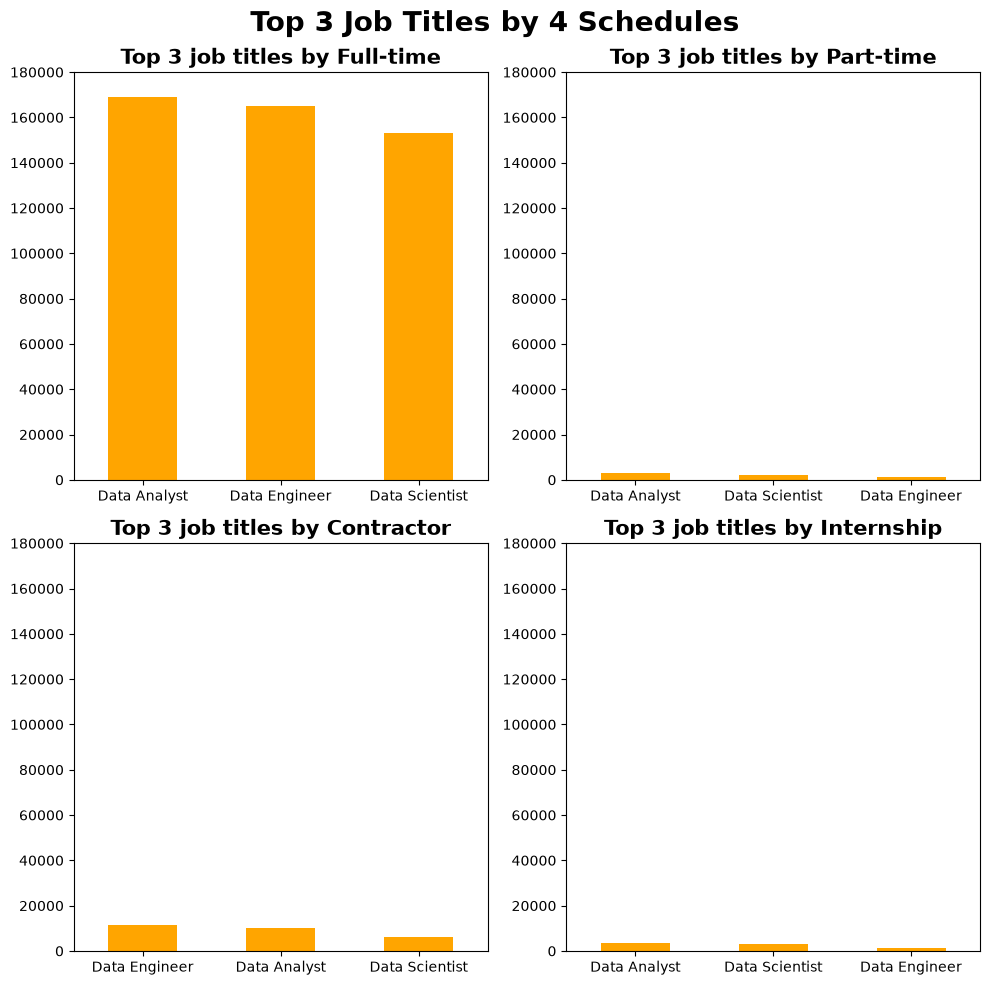

In [84]:
fig, ax = plt.subplots(2, 2, figsize = (10,10))
ax=ax.flatten()


for index, schedule in enumerate(schedules):
    df_schedule = df.copy()[df['job_schedule_type'] == schedule]['job_title_short'].value_counts().head(3)
    df_schedule = df_schedule.reset_index(name='job_count')
    df_schedule.plot(kind='bar', x = 'job_title_short', y = 'job_count', ax=ax[index], color ='orange')

    ax[index].set_title(f'Top 3 job titles by {schedule}', fontsize = 15, fontweight = 'bold')
    ax[index].set_xticklabels(df_schedule['job_title_short'].unique(), rotation = 0)
    ax[index].set_xlabel('')
    ax[index].legend().set_visible(False)
    ax[index].set_ylim(0, 180000)

fig.suptitle('Top 3 Job Titles by 4 Schedules', fontsize = 20, fontweight = 'bold')
fig.tight_layout()
plt.show()

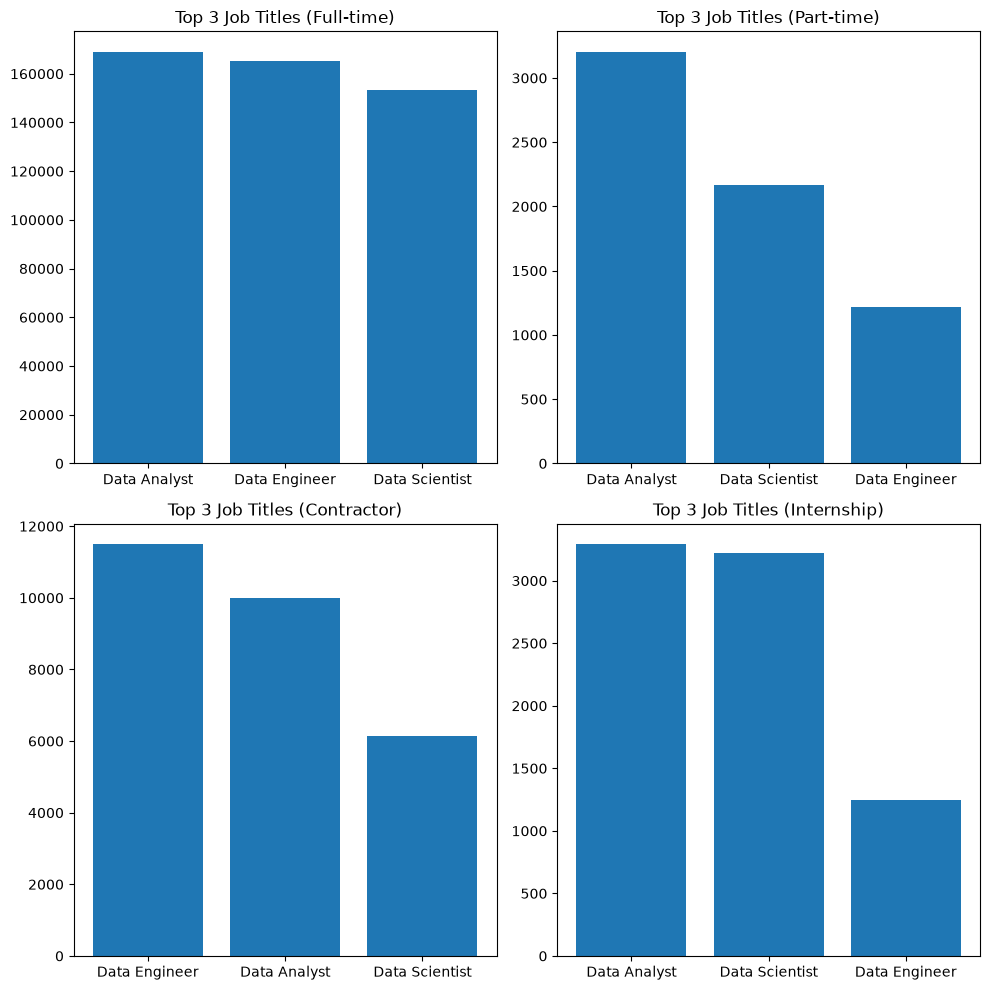

In [8]:
fig, ax = plt.subplots(2, 2, figsize = (10,10))

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule]
    job_titles = df_schedule['job_title_short'].value_counts().head(3)
    ax[i//2, i%2].bar(job_titles.index, job_titles.values)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles ({schedule})')

fig.tight_layout()
plt.show()

## 🟥 Top Skills for Job Roles Subplots (2.13.3) - Problem

Create a subplot with 3 rows and 1 column:

* In each subplot, plot a horizontal bar chart of the top 3 job skills by the number of job postings for each job title (Senior Data Scientist, Senior Data Engineer, and Senior Data Analyst).
* Use fig.tight_layout() to adjust the spacing between subplots and invert_yaxis() to invert the y-axis in each subplot.

In [9]:
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']

In [10]:
#Explode the job_skills column
df_explode = df.copy().explode('job_skills')

#Pivot skill, job title short in order to count
df_skill_pivot = df_explode.pivot_table(index=['job_skills', 'job_title_short'], aggfunc='size')

#Reset index and convert the pivot table into DataFrame
df_skill = df_skill_pivot.reset_index(name='skill_count')

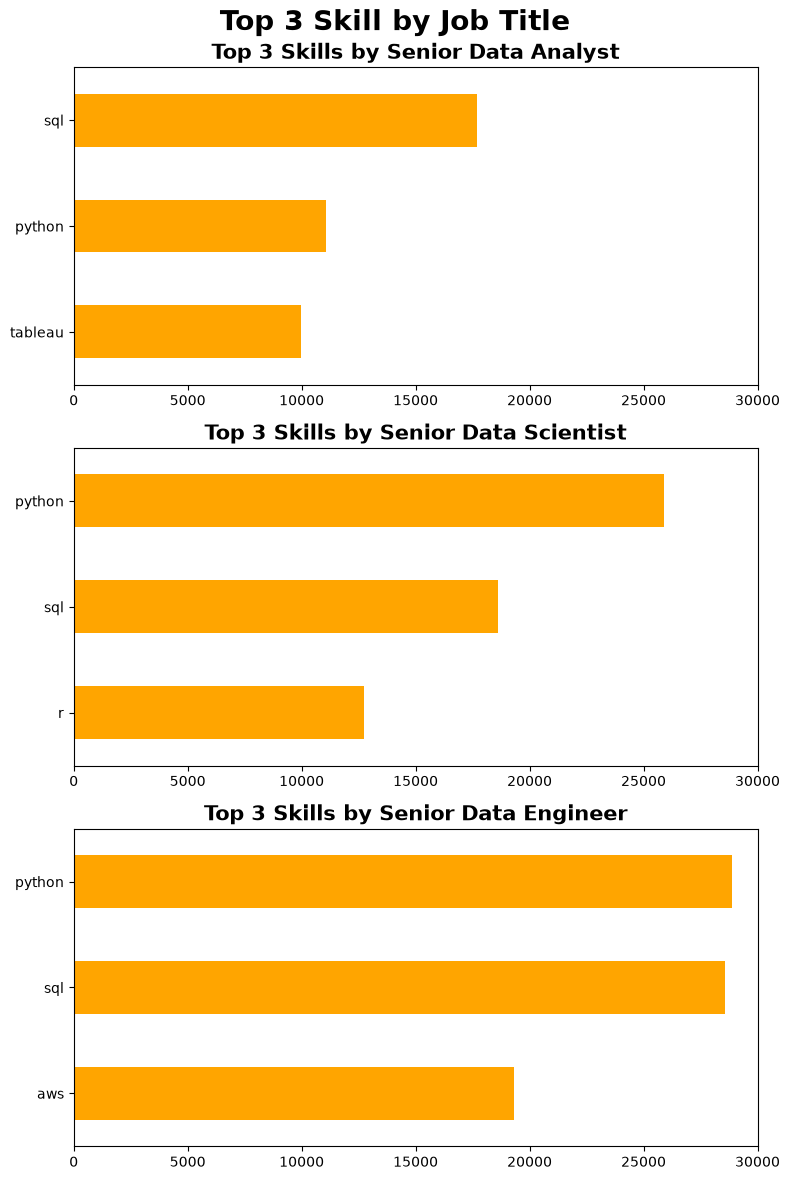

In [79]:
#Creat 3 plot into 1 column
fig, ax = plt.subplots(3, 1, figsize = (8, 12))

for index, role in enumerate(job_roles):
    df_role = df_skill[df_skill['job_title_short'] == role][['job_skills', 'skill_count']].sort_values(ascending  = False, by = 'skill_count').head(3)
    df_role.plot(kind = 'barh', y = 'skill_count', x = 'job_skills',  ax = ax[index], color = 'orange')

    ax[index].set_title(f'Top 3 Skills by {role}', fontsize = 15, fontweight = 'bold')
    ax[index].set_xlim(0, 30000)
    ax[index].set_ylabel('')
    ax[index].invert_yaxis()
    ax[index].legend().set_visible(False)

fig.suptitle('Top 3 Skill by Job Title', fontsize = 20, fontweight = 'bold')
fig.tight_layout()
plt.show()

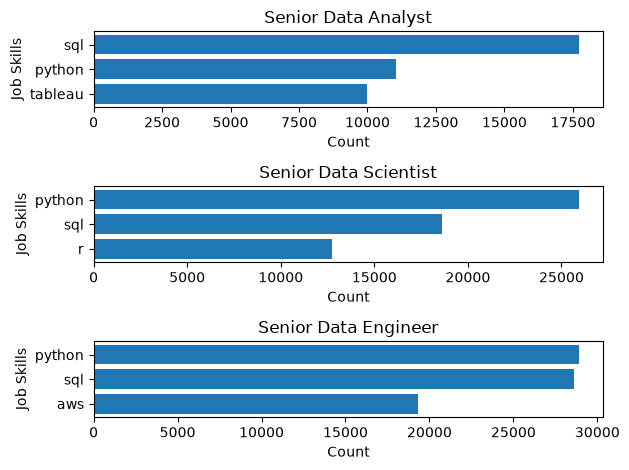

In [80]:
df_skills = df.explode('job_skills')
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(len(job_roles), 1)
for i, role in enumerate(job_roles):
    role_skills = df_skills[df_skills['job_title_short'] == role]['job_skills'].value_counts().head(3)
    ax[i].barh(role_skills.index, role_skills.values)
    ax[i].set_title(role)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('Job Skills')
    ax[i].invert_yaxis()
fig.tight_layout()
plt.show()